# `dtalite-simulation` — the third EDOC row, the first DETERMINISTIC-track external engine

**What.** `dtalite-simulation` wraps DTALite 0.8.1's mesoscopic queue simulator (Zhou & Taylor
2014) — the wheel's `simulation()` entry, a sub-second queue-DNL map from a plan artifact
(`vehicle.csv`) to an experienced-time artifact (`trajectory.csv`) — as the third **EDOC-1**
observational row ([ADR-036](../../docs/design/adr-036-external-dynamic-observational-certificate.md) /
[ADR-040](../../docs/design/adr-040-dtalite-simulation.md)). It is a DIFFERENT engine from
`dtalite-tap` (adr-029): that row is the wheel's `assignment()` static Frank-Wolfe on an
exactly-mapped BPR (certified against the *declared* cost law); `simulation()` has **no declared
cost law** — *the engine is the instance*, and the certifier re-derives every scored number by
re-running the pinned engine on the model's emitted plans (G1 replay fidelity). This is an EDOC
producer, **not** a `TrafficAssignmentModel` — never in `MODEL_REGISTRY`.

**Score.** The engine is **deterministic**: its only RNG is an LCG re-seeded `101 + time_step`
at every step, so it consumes no seed (`seedable=False`, `seed_list=()`, no macroreps —
disclosed). The score is the single **frozen-field best-response gap `RG_D1`** — a door-to-door
quantity on its own leaderboard scale, **not** the Wardrop `relative_gap` of the static rows nor
`dtalite-tap`'s `relative_gap` (same wheel, different engine), so it never enters those tables
(R8 non-comparability).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every quantity below — the
negative-control separation anchors, the certified `RG_D1`, the resolution delta, and the
boost-window censor — is recomputed here by the same substrate the benchmark uses (`EdocEvaluator`
via the certifier-owned replay runner). The model emits artifacts; the certifier, model-blind,
re-runs the pinned `OMP_NUM_THREADS=1` replay and recomputes the score (a doctored experienced
record diverges from the byte-deterministic replay and is censored).

In [1]:
%matplotlib inline
# Setup. `dtalite-simulation` runs the DTALite 0.8.1 wheel's simulation() engine ONLY in
# throwaway subprocesses (the wheel prints a banner and ctypes-loads an OpenMP .so into the
# host on import — adr-029), so availability is a find_spec probe that NEVER imports. This
# guard raises politely when the wheel is absent rather than failing with a G0 error later.
import importlib.util

if importlib.util.find_spec("DTALite") is None:
    raise RuntimeError(
        "this tutorial needs the DTALite engine wheel: `pip install tabench[dtalite]` "
        "(pinned DTALite==0.8.1; see docs/design/adr-040-dtalite-simulation.md)"
    )

import matplotlib.pyplot as plt

from tabench.models.adapters.dtalite_simulation import (
    DTALiteSimulationAdapter,
    build_dtalite_corridor_scenario,
    certify_emitted,
    negative_control_separation,
    reference_scenario,
)

## The instance

The pinned reference is a **two-route corridor**: `O ->a1-> MA ->a2-> D` (fftt 2x300 s, the
1-lane 600 veh/h bottleneck route) vs `O ->b1-> MB ->b2-> D` (2x420 s, 2-lane). 1000 agents
depart 2-per-6-s-slot over 50 min (1200 veh/h aggregate against the engine's measured ~600 veh/h
per-route transfer-admission law), so the step-0 Frank-Wolfe split piles the transfer queue onto
route A and separates from the MSA-converged blend. The engine identity + version, the `.so`
determinism pins (`OMP_NUM_THREADS=1`), the 7->13 h engine period, the 6 s dynamics grid, the
boost-window constant, and every floor/deadline dial are **all inside the content hash** — the
engine is part of the instance. `seed_list=()` is the deterministic-track disclosure.

In [2]:
scenario = reference_scenario()

print(f"instance       : {scenario.name}")
print(f"content hash   : {scenario.content_hash()}")
print(f"engine (pinned): {scenario.engine} {scenario.engine_version}")
print(f"seed list      : {scenario.seed_list}   (deterministic track: no seed, no macroreps)")
print(f"network        : {scenario.n_edges} edges, {scenario.n_agents} agents (all O -> D)")
print(f"lanes          : {scenario.lanes_of()}   (a1/a2 are the 1-lane 600 veh/h bottleneck)")
print(f"grid           : dt = {scenario.dt:g}s x {scenario.n_intervals}  "
      f"(6 s engine dynamics grid; departures on-grid)")
print(f"declared       : separation >= {scenario.separation_factor:g}x, "
      f"floor {scenario.floor_seconds:g}s, replay deadline {scenario.replay_deadline_s:g}s")

instance       : dtalite-simulation-ref
content hash   : f3bf543b1fc21e08dba9c5078d0114caea5ac26fcff9211c6e61ac6b9362d7c7
engine (pinned): DTALite 0.8.1
seed list      : ()   (deterministic track: no seed, no macroreps)
network        : 4 edges, 1000 agents (all O -> D)
lanes          : {'a1': 1, 'a2': 1, 'b1': 2, 'b2': 2}   (a1/a2 are the 1-lane 600 veh/h bottleneck)
grid           : dt = 6s x 3600  (6 s engine dynamics grid; departures on-grid)
declared       : separation >= 5x, floor 10s, replay deadline 30s


## The negative control — step-0 split vs MSA-converged

`RG_D1` must *separate* a bad assignment from a good one. The control is the step-0 Frank-Wolfe
split emitted as-is (`iterations=0`); the converged state runs the certifier-owned MSA `1/(k+2)`
best-response blend (hash-derived switching picks — no cross-version RNG dependence). The gate
compares **floor-displayed** values (`max(rg, floor_gap)` each side), so a self-certifying
shared-transfer topology whose anchors both collapse to `RG_D1 = 0` separates ~1x and is
**refused at construction** — this cell also separation-vets the topology, which
`certify_emitted` requires. Two emissions + four certifier replays, ~2 s (no macroreps).

In [3]:
anchors = negative_control_separation(scenario, wall_seconds=600.0)

print(f"step-0 control : RG_D1 {anchors['control_rg_d1']:.5f}   (the FW split, piled on route A)")
print(f"MSA converged  : RG_D1 {anchors['converged_rg_d1']:.5f}")
print(f"separation     : {anchors['separation']:.2f}x   (floor-displayed; "
      f"declared >= {anchors['separation_factor']:g}x)")

step-0 control : RG_D1 0.37224   (the FW split, piled on route A)
MSA converged  : RG_D1 0.05031
separation     : 7.40x   (floor-displayed; declared >= 5x)


## Certify the row

The model emits its final MSA plans `P`; `X` and the frozen field are defined by the adapter's own
pinned replay of `P`. The certifier re-runs the identical replay and checks G0 pins (engine
version + inert seed), G1 replay fidelity **twice** (the determinism double on the raw
`trajectory.csv` bytes — byte-deterministic at `OMP_NUM_THREADS=1`), G2 demand bijection with
exact on-grid departures, G3 completion census (from `current_link_seq_no` + non-filler chains —
never the dead `loaded_status` column), G4 conservation, the resolution-floor gate, and `RG_D1`
against the certifier-owned time-dependent shortest path. With no engine router the substrate
TD-SP is normative-only, so R3 is a harness field-arithmetic self-cross-check (disclosed).

In [4]:
emitted = DTALiteSimulationAdapter(iterations=16).emit(scenario, wall_seconds=600.0)
m = certify_emitted(scenario, emitted, wall_seconds=600.0)

print(f"feasible       : {m['feasible']:.0f}")
print(f"RG_D1          : {m['rg_d1']:.5f}   "
      f"(floor_gap {m['floor_gap']:.4f} -> sub_floor={m['sub_floor']:.0f}: "
      f"{'RANKED' if m['sub_floor'] == 0 else 'at floor'})")
print(f"resolution     : delta {m['delta']:.2f}s <= floor {scenario.floor_seconds:g}s   "
      f"(field represents experienced costs)")
print(f"delivery       : max backlog {m['max_backlog']:.0f}s, br_coverage {m['br_coverage']:.2f}")
print(f"R3 self-check  : max {m['r3_max_s']:.3f}s <= tol {m['r3_tolerance_s']:g}s")

feasible       : 1
RG_D1          : 0.05031   (floor_gap 0.0118 -> sub_floor=0: RANKED)
resolution     : delta 1.75s <= floor 10s   (field represents experienced costs)
delivery       : max backlog 0s, br_coverage 1.00
R3 self-check  : max 0.000s <= tol 15s


## The boost-window censor — an instance-design defense (pair 12)

DTALite's `simulation()` carries an off-by-units bug: the discharge capacity is boosted x10 in
the **last 720 six-second intervals** of *any* horizon (the last 72 min). A congested emission
that finishes inside that window has boost-deflated experienced times. The reference exits hours
before its 4.8 h onset (boost-clean), but a **1 h-horizon variant of the same topology** puts the
onset at `3600 - 4320 = -720 s < 0` — the entire horizon is boost-covered, so the instance is
degenerate. The certifier **censors** it (`feasible=0`, `boost_crossing_n = n_agents`), the
in-loop MSA census **raises**, and the separation gate **refuses** it. Same topology digest as the
reference (n_intervals is not a topology field), so it is already vetted.

In [5]:
boost_variant = build_dtalite_corridor_scenario("dtalite-boost-demo", n_intervals=600)  # 1 h
onset = boost_variant.dt * boost_variant.n_intervals - 720 * 6.0

em0 = DTALiteSimulationAdapter(iterations=0).emit(boost_variant, wall_seconds=600.0)
cm = certify_emitted(boost_variant, em0, wall_seconds=600.0)
print(f"boost onset    : {onset:.0f}s < 0  -> the whole 1 h horizon is inside the boost window")
print(f"certify        : feasible {cm['feasible']:.0f}, "
      f"boost_crossing_n {cm['boost_crossing_n']:.0f} (every agent boost-exposed)")

try:
    DTALiteSimulationAdapter(iterations=1).emit(boost_variant, wall_seconds=600.0)
except ValueError as exc:
    print(f"in-loop MSA    : RAISED -> {str(exc).splitlines()[0][:70]}...")

boost onset    : -720s < 0  -> the whole 1 h horizon is inside the boost window
certify        : feasible 0, boost_crossing_n 1000 (every agent boost-exposed)
in-loop MSA    : RAISED -> MSA iterate 0: 1000 agent(s) exit inside the engine's x10 discharge-bo...


## Visualize

One figure, every mark certified above: the step-0 control and the MSA-converged `RG_D1`
(floor-displayed), the resolution floor, and the separation factor. The gap between the two bars
*is* what `RG_D1` exists to measure — a bad assignment (the FW split, transfer queue on route A)
vs a near-equilibrium blend, on the frozen realized field. (`RG_D1` is a scalar on its own
leaderboard scale, so this plots the certified quantities directly — a house chart, not
`tabench.viz`; the bottleneck/newell/matsim precedent, adr-035.)

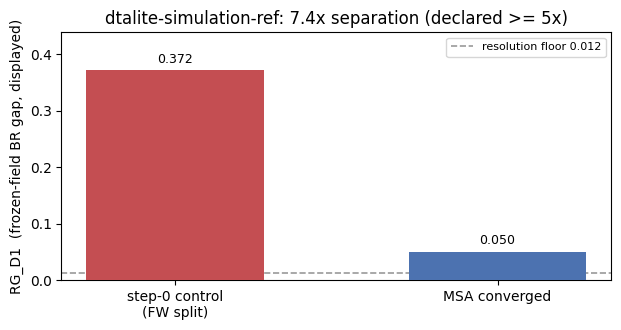

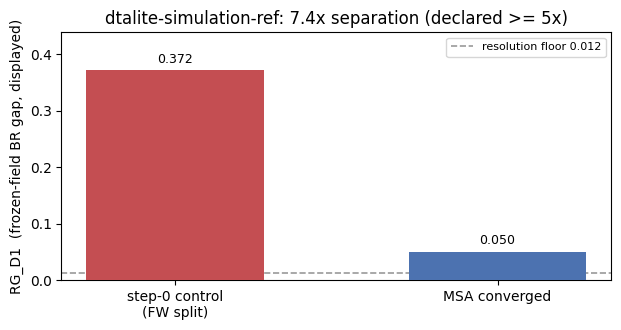

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
labels = ["step-0 control\n(FW split)", "MSA converged"]
vals = [anchors["control_displayed"], anchors["converged_displayed"]]
bars = ax.bar(labels, vals, color=["#c44e52", "#4c72b0"], zorder=3, width=0.55)
ax.axhline(m["floor_gap"], color="#9a9a9a", ls="--", lw=1.2,
           label=f"resolution floor {m['floor_gap']:.3f}")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.008, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("RG_D1  (frozen-field BR gap, displayed)")
ax.set_ylim(0, max(vals) * 1.18)
ax.set_title(f"{scenario.name}: {anchors['separation']:.1f}x separation "
             f"(declared >= {anchors['separation_factor']:g}x)")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig

## Takeaways & pointers

- **Deterministic track, structurally.** The engine consumes no seed (the LCG is time-step-keyed),
  so `seed_list=()`, there are no macroreps, and `per_seed_scenarios` refuses the empty list —
  macrorep misuse is impossible. `scenario.seed` stays hashed but is engine-inert.
- **`rc=0` silent failures are the engine's signature.** Pre-period drops head-block later
  same-first-link agents, period-end truncation leaves `07:00:00` filler chains, and an unsorted
  `vehicle.csv` silently corrupts the later-departing agent — all at exit code 0. Success is
  DEFINED by the parse + completion census, never `returncode` (the adr-029 doctrine); the
  certifier writes `vehicle.csv` itself, sorted by `(departure_time, agent)`.
- **`OMP_NUM_THREADS=1` is a CORRECTNESS pin, not hygiene.** The engine's `#pragma omp parallel
  for` over a shared `std::deque` diverges and SIGSEGVs at OMP>1 on a congested net; the child env
  always pins it (beating a hostile parent), which is why the raw trajectory bytes are
  reproducible and G1 is byte-exact.
- **`RG_D1` is not Wardrop `relative_gap`** and not `dtalite-tap`'s `relative_gap` (same wheel,
  different engine). A separate leaderboard table (R8); never compared across engines/tracks.
- **Provenance vs score.** DTALite's printed gap/summary and its debug logs are provenance only;
  `X` and the frozen field are defined by the pinned replay map, which is why a self-reported
  record is never gated.

See [ADR-040](../../docs/design/adr-040-dtalite-simulation.md) for the measured family constants
(the R4 re-derivation, the head-block/lull/boost hazards, the fftt-column probe) and
[ADR-036](../../docs/design/adr-036-external-dynamic-observational-certificate.md) for the
certificate.